Loading model from: result/models/VariableReacher_Task0_rank0_JointTrain_init/best.pth
[Env] Created VariableReacherEnv for Task 0
Model loaded successfully. Starting evaluation with eval_mode=False (MPPI)...


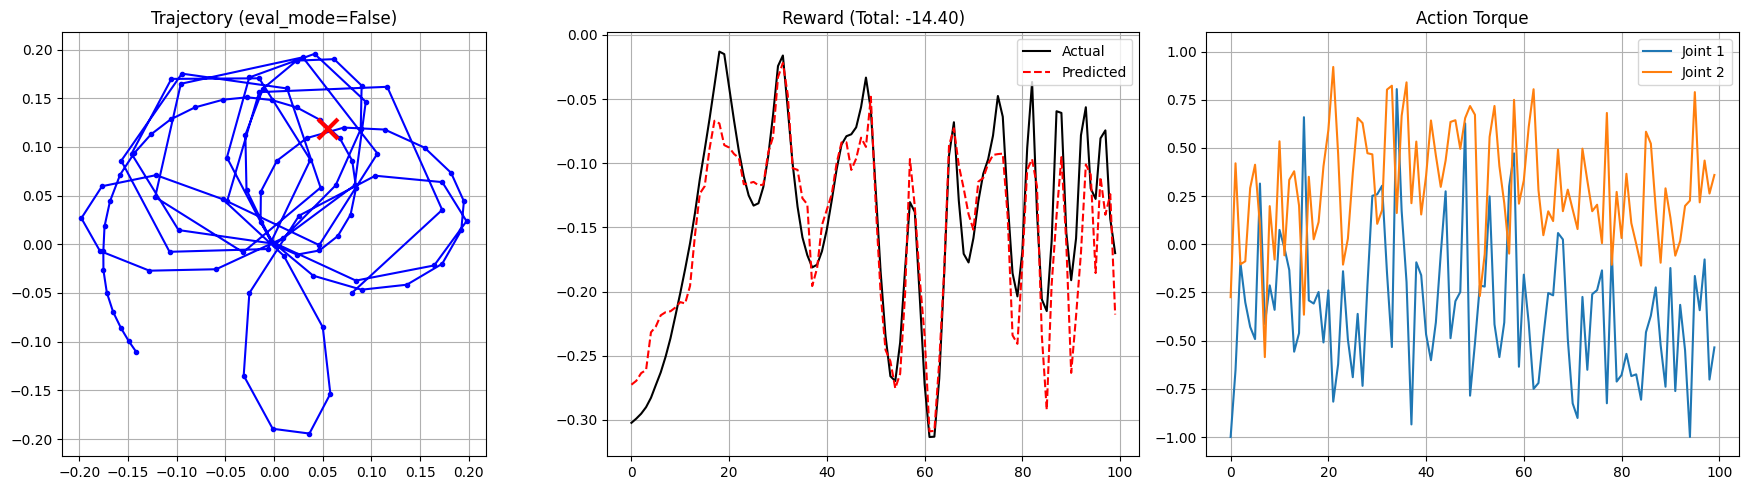

Loading model from: result/models/VariableReacher_Task1_rank0_JointTrain_1st/best.pth
[Env] Created VariableReacherEnv for Task 1
Model loaded successfully. Starting evaluation with eval_mode=False (MPPI)...


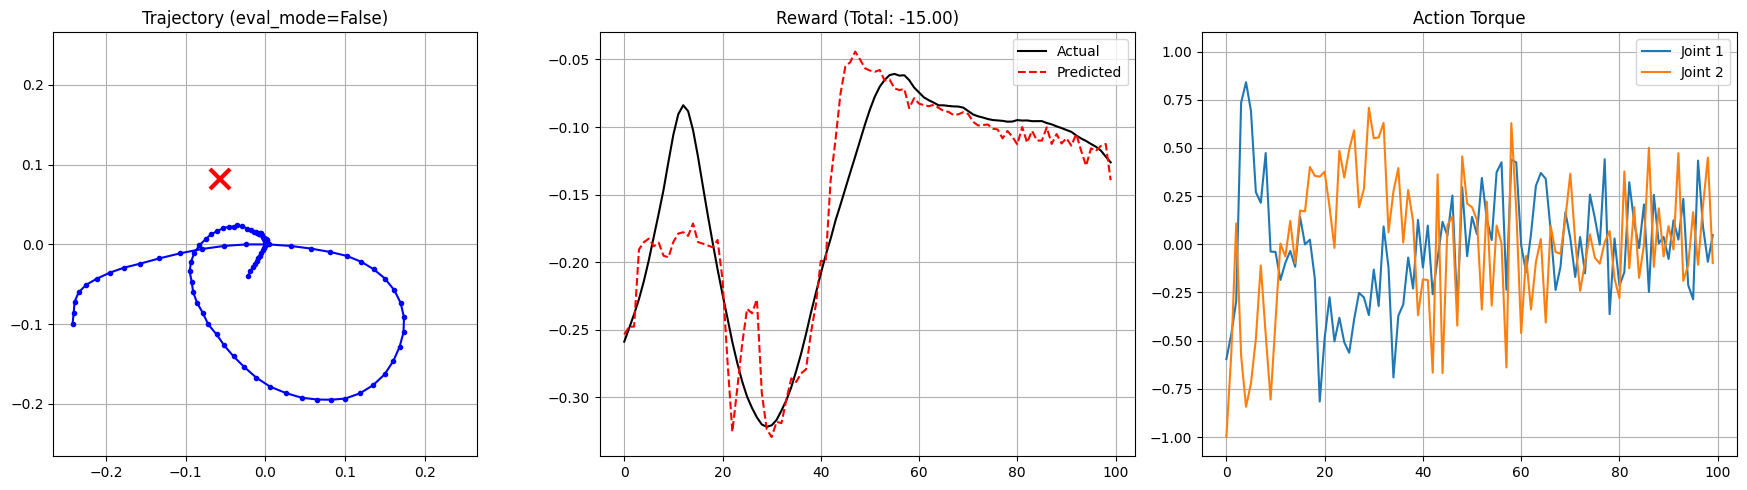

Loading model from: result/models/VariableReacher_Task2_rank0_JointTrain_1st/best.pth
[Env] Created VariableReacherEnv for Task 2
Model loaded successfully. Starting evaluation with eval_mode=False (MPPI)...


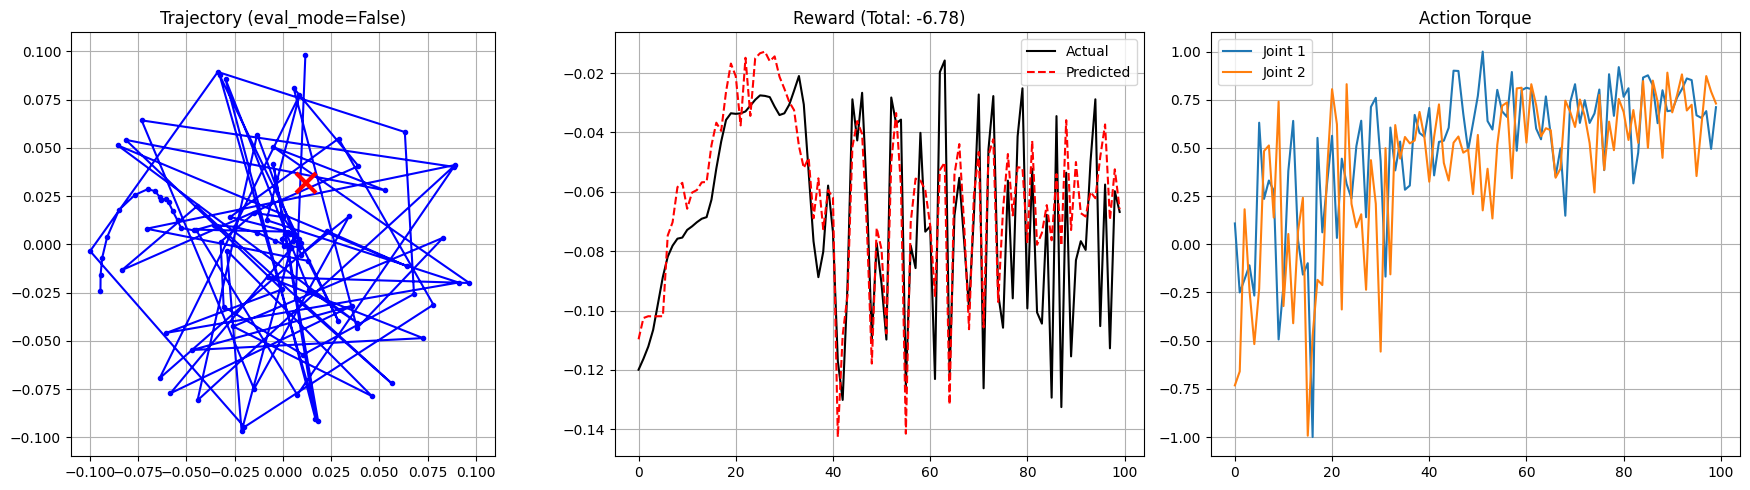

Loading model from: result/models/VariableReacher_Task0_rank4_JointTrain_init/best.pth
[Env] Created VariableReacherEnv for Task 0
Model loaded successfully. Starting evaluation with eval_mode=False (MPPI)...


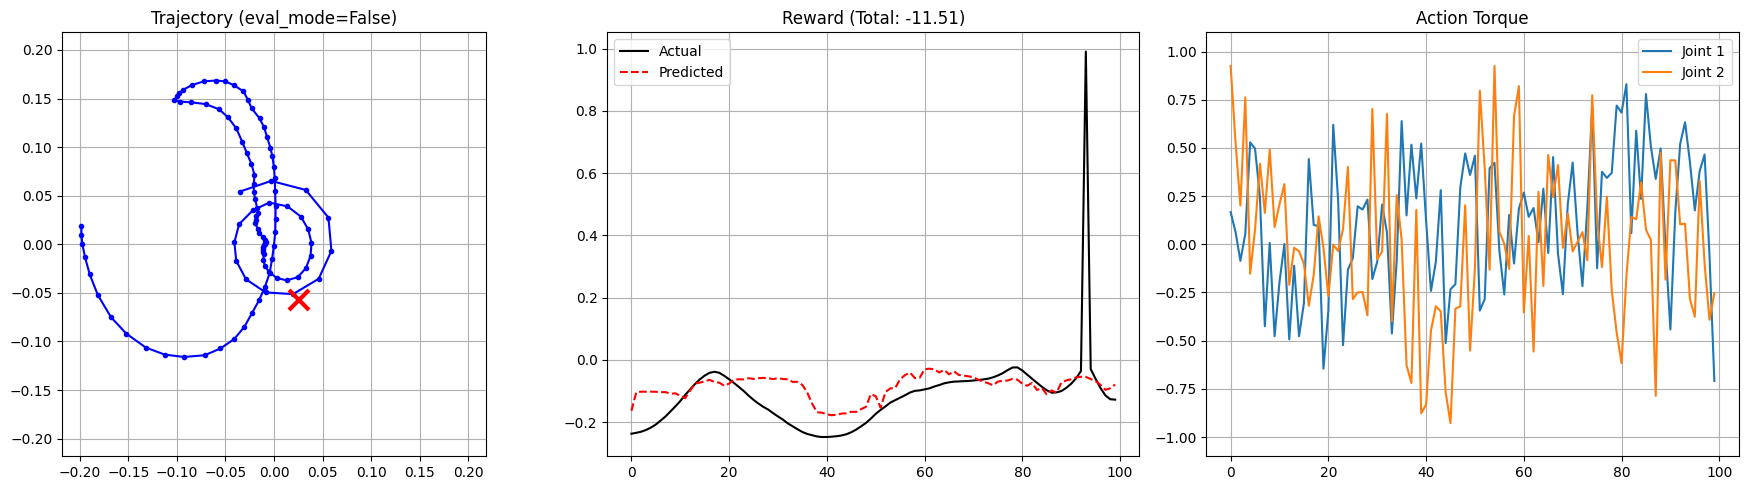

Loading model from: result/models/VariableReacher_Task1_rank4_JointTrain_1st/best.pth
[Env] Created VariableReacherEnv for Task 1
Model loaded successfully. Starting evaluation with eval_mode=False (MPPI)...


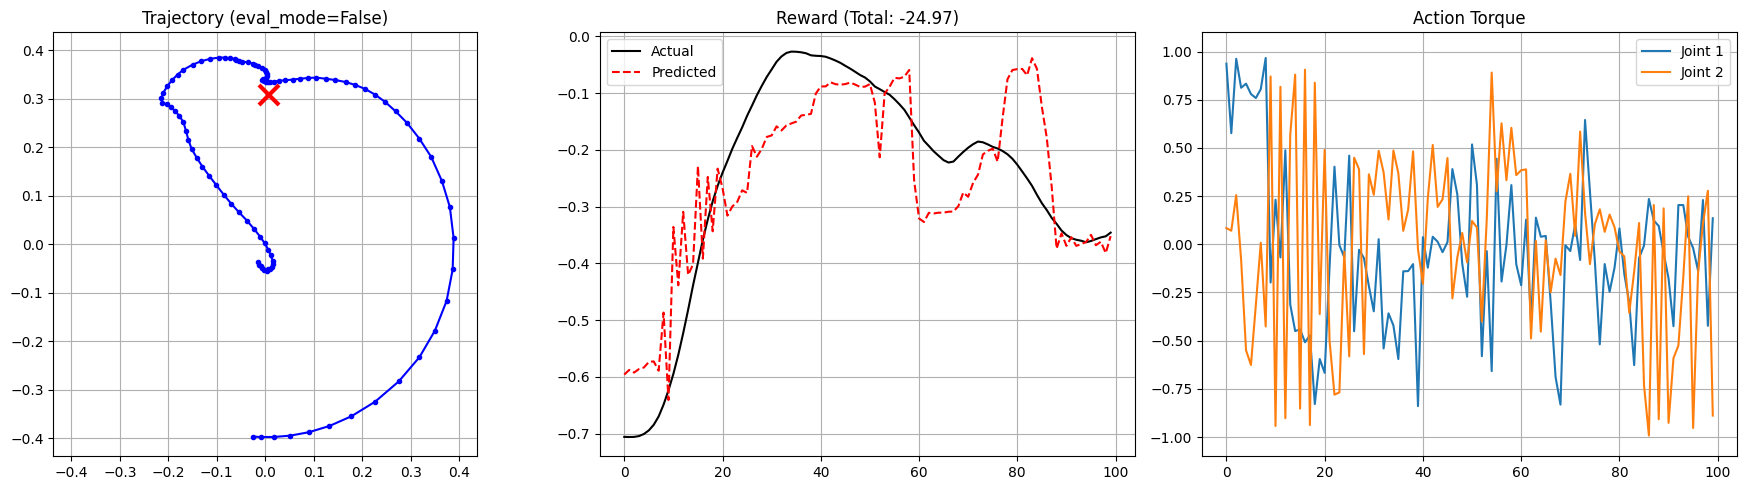

Model not found: result/models/VariableReacher_Task2_rank4_JointTrain_1st/best.pth
Please edit the MODEL_PATH in the script.


In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# プロジェクトのモジュールを読み込み
from tdmpc2lora_tmp.config import Config
from tdmpc2lora_tmp.train_env import make_env
from tdmpc2lora_tmp.model import TDMPC2, two_hot_inv

# 学習済みモデルのパス (ご自身の環境に合わせて変更してください)
# 例: "result/models/VariableReacher_Task0_rank4_JointTrain_init/best.pth"

# ==========================================

def evaluate_standalone(model_path, task_id=0, lora_rank=4):
    print(f"Loading model from: {model_path}")
    
    # 1. Configの構築 (学習時と同じ重要設定にする)
    cfg = Config()
    cfg.task = "VariableReacher"
    cfg.task_id = task_id
    cfg.num_tasks = 4
    cfg.lora_rank = lora_rank
    cfg.device = "cpu" # 可視化はCPUでOK
    
    # 【重要】学習時と同じ設定を強制
    cfg.horizon = 40
    cfg.vmin = -1.0
    cfg.action_dim = 2
    
    # 2. 環境とエージェントの準備
    env = make_env(cfg)
    agent = TDMPC2(cfg)
    
    # 3. 重みのロード
    if not Path(model_path).exists():
        print(f"[Error] File not found: {model_path}")
        print("パスを確認してください。")
        return

    ckpt = torch.load(model_path, map_location="cpu", weights_only=False)
    agent.model.load_state_dict(ckpt["model"], strict=False)
    agent.eval()
    
    print("Model loaded successfully. Starting evaluation with eval_mode=False (MPPI)...")

    # 4. エピソード実行 (データ収集)
    obs, _ = env.reset()
    done = False
    
    history = {
        "tip_pos": [], "target_pos": [], "actions": [],
        "actual_rewards": [], "pred_rewards": []
    }
    
    step = 0
    while not done:
        # --- ここがポイント: eval_mode=False でMPPIを使う ---
        action = agent.act(obs, eval_mode=False, task_idx=task_id)
        
        # モデルの予測報酬も記録 (診断用)
        with torch.no_grad():
            if obs.ndim == 1: obs_t = obs.unsqueeze(0)
            z = agent.model.encode(obs_t, task_idx=torch.tensor([task_id]))
            a_t = action.unsqueeze(0)
            r_dist = agent.model.reward(z, a_t, task_idx=torch.tensor([task_id]))
            r_pred = two_hot_inv(r_dist, cfg).item()
            history["pred_rewards"].append(r_pred)

        # 環境ステップ
        next_obs, reward, done_tensor, info = env.step(action)
        done = bool(done_tensor.item())
        
        # 記録
        # VariableReacherの観測仕様: [cos, sin, vel(2), target(2)]
        # 先端位置は obs から逆算するか、環境の内部状態から取得する必要があるが、
        # ここでは簡易的に内部変数を使います（render用ロジック）
        tip_pos = env.unwrapped._get_tip_pos() # VariableReacherEnvのメソッド
        target_pos = env.unwrapped.target
        
        history["tip_pos"].append(tip_pos)
        history["target_pos"].append(target_pos)
        history["actions"].append(action.numpy())
        history["actual_rewards"].append(reward.item())
        
        obs = next_obs
        step += 1
        if step >= 100: break

    # 5. 可視化
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: 軌跡
    tips = np.array(history["tip_pos"])
    targets = np.array(history["target_pos"])
    axes[0].plot(tips[:, 0], tips[:, 1], 'b.-', label="Agent")
    axes[0].plot(targets[0, 0], targets[0, 1], 'rx', markersize=15, markeredgewidth=3, label="Target")
    # x_lim_abs_max = max(abs(tips[:, 0].min()), abs(tips[:, 0].max()), abs(targets[:, 0].min()), abs(targets[:, 0].max()), 2.2)
    # y_lim_abs_max = max(abs(tips[:, 1].min()), abs(tips[:, 1].max()), abs(targets[:, 1].min()), abs(targets[:, 1].max()), 2.2)
    # axes[0].set_xlim(-x_lim_abs_max, x_lim_abs_max); axes[0].set_ylim(-y_lim_abs_max, y_lim_abs_max)
    data_max = max(
        np.abs(tips[:, 0]).max(), 
        np.abs(targets[:, 0]).max(), 
        np.abs(tips[:, 1]).max(), 
        np.abs(targets[:, 1]).max()
    )
    limit = data_max * 1.1
    limit = max(limit, 0.1) 
    axes[0].set_xlim(-limit, limit)
    axes[0].set_ylim(-limit, limit)
    axes[0].set_aspect('equal')
    axes[0].set_title("Trajectory (eval_mode=False)")
    axes[0].grid(True)

    axes[0].set_aspect('equal')
    axes[0].set_title("Trajectory (eval_mode=False)")
    axes[0].grid(True)
    
    # Plot 2: 報酬 (現実 vs 予測)
    steps = range(len(history["actual_rewards"]))
    axes[1].plot(steps, history["actual_rewards"], 'k-', label="Actual")
    axes[1].plot(steps, history["pred_rewards"], 'r--', label="Predicted")
    axes[1].set_title(f"Reward (Total: {sum(history['actual_rewards']):.2f})")
    axes[1].legend()
    axes[1].grid(True)
    
    # Plot 3: アクション
    actions = np.array(history["actions"])
    axes[2].plot(steps, actions[:, 0], label="Joint 1")
    axes[2].plot(steps, actions[:, 1], label="Joint 2")
    axes[2].set_ylim(-1.1, 1.1)
    axes[2].set_title("Action Torque")
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    for rank in [0, 4]:
        model_path_base=Path("result/models")
        postfix_list = [f"_Task0_rank{rank}_JointTrain_init", 
                        f"_Task1_rank{rank}_JointTrain_1st", 
                        f"_Task2_rank{rank}_JointTrain_1st",
                        # f"_Task1_rank{rank}_JointTrain_2nd", 
                        ]
        model_name = "best.pth"
        for postfix in postfix_list:
            model_path = model_path_base / f"VariableReacher{postfix}" / model_name
            # モデルファイルが存在するか確認してから実行
            if Path(model_path).exists():
                evaluate_standalone(model_path, task_id=int(postfix[5]), lora_rank=rank)
                # visualize_episode(model_path, task_id=int(postfix[5]), save_name=f"debug{postfix}.png")
            else:
                print(f"Model not found: {model_path}")
                print("Please edit the MODEL_PATH in the script.")